In [1]:
!pip install -U langgraph langsmith langchain_openai

  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached uuid_utils-0.14.1-cp39-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached zstandard-0.25.0-cp312-cp312-win_amd64.whl.metadata (3.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached ormsgpack-1.12.2-cp312-cp312-win_amd64.whl.metadata (3.3 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached tiktoken-0.12.0-cp312-cp312-win_amd64.whl.metadata (6.9 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached s

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.1 which is incompatible.
tensorflow-intel 2.18.0 requires tensorboard<2.19,>=2.18, but you have tensorboard 2.19.0 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
from uuid import uuid4

In [6]:
unique_id = uuid4().hex[0:8]
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_PROJECT'] = f'LangGraph Tutorial - {unique_id}'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = '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'

In [6]:
unique_id

'cd843c69'

In [7]:
os.environ['OPENAI_API_KEY'] = ''

Part 1 : Build Basic Chatbot

In [8]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [9]:
#챗봇의 뼈대 생성
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [10]:
from langchain_openai import ChatOpenAI

In [11]:
llm = ChatOpenAI(
    model = 'gpt-4o-mini',
    temperature=0,
)

In [12]:
def chatbot(state: State):
    return {'messages' : [llm.invoke(state['messages'])]}
graph_builder.add_node('chatbot', chatbot)

In [13]:
graph_builder.add_edge(START, 'chatbot')

In [14]:
graph_builder.add_edge('chatbot', END)

In [15]:
graph = graph_builder.compile()

In [16]:
from IPython.display import Image, display

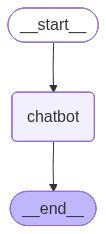

In [19]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [20]:
while True:
    user_input = input('User: ')
    if user_input.lower() in ['quit', 'exit', 'q']:
        print('Goodbye!')
        break
    for event in graph.stream({'messages': ('user', user_input)}):
        for value in event.values():
            print('Assistant', value['messages'][-1].content)

Assistant As of my last knowledge update in October 2023, LangGraph is a framework designed to facilitate the development of applications that leverage large language models (LLMs) and other AI technologies. It focuses on creating a structured way to build and manage complex workflows involving natural language processing (NLP) tasks.

Key features of LangGraph typically include:

1. **Graph-Based Structure**: LangGraph uses a graph-based approach to represent the relationships and workflows between different components, such as data sources, processing nodes, and output targets. This allows for a more organized and modular design.

2. **Integration with LLMs**: The framework is designed to work seamlessly with various large language models, enabling developers to easily incorporate advanced NLP capabilities into their applications.

3. **Customizability**: LangGraph allows developers to create custom nodes and workflows tailored to specific use cases, making it versatile for different

part 2 : Enhancing the Chatbot with tools

In [26]:
!pip install -qU duckduckgo-search langchain-community


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from langchain_community.tools import DuckDuckGoSearchRun

In [29]:
!pip install ddgs


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
tool = DuckDuckGoSearchRun()
tools = [tool]
tool.invoke("what's a 'node' in LangGraph?")

'3 weeks ago - Complex workflows often involve cyclic dependencies, where the outcome of one step depends on previous steps in the loop. Nodes: In LangGraph, nodes represent individual components or agents within an AI workflow. November 25, 2025 - If you read my earlier pieces on reducers and state updates, you’ll notice that node logic often results in new data being produced, which your reducers then merge into the global state. After the logic runs, the node spits out something new — usually part of the state. LangGraph takes this result, merges it into the state (thanks to reducers), and carries the updated backpack forward to the next node. September 16, 2025 - They’re pieces you already know, just arranged in a smarter way. A Node is basically “a single action.” Imagine breaking your workday into steps: checking email, making coffee, writing code, or scheduling a meeting. November 19, 2025 - Here are the four key components that power this framework: Nodes: Nodes represent indiv

part 1과 동일하지만, bind_tools를 LLM에 추가했습니다. 이를 통해 LLM이 검색 엔진을 사용하려고 할 때 올바른 JSON 형식을 알 수 있습니다.

In [19]:
from typing import Annotated
from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages

In [20]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

llm = ChatOpenAI(
    model='gpt-4o-mini',
    temperature=0,
)
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

graph_builder.add_node('chatbot', chatbot)

In [21]:
import json
from langchain_core.messages import ToolMessage

In [22]:
class BasicToolNode:
    def __init__(self, tools:list) ->None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get('messages', []):
            message = messages[-1]
        else:
            raise ValueError('No message found in input')
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call['name']].invoke(tool_call['args'])
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name = tool_call['name'],
                    tool_call_id = tool_call['id'],
                )
            )
        return {'messages': outputs}
    
tool_node = BasicToolNode(tools = [tool])
graph_builder.add_node('tools', tool_node)

In [23]:
from typing import Literal

In [24]:
def route_tools(
        state: State,
) -> Literal['tools', '__end__']:
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get('messages', []):
        ai_message = messages[-1]
    else:
        raise ValueError(f'No messages found in input state to tool_edge: {state}')
    if hasattr(ai_message, 'tool_calls') and len(ai_message.tool_calls) > 0:
        return 'tools'
    return '__end__'

graph_builder.add_conditional_edges(
    'chatbot',
    route_tools,
    {'tools': 'tools', '__end__':'__end__'},
)

graph_builder.add_edge('tools', 'chatbot')
graph_builder.add_edge(START, 'chatbot')
graph = graph_builder.compile()

In [25]:
from IPython.display import Image, display

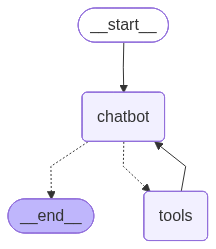

In [26]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [27]:
from langchain_core.messages import BaseMessage

In [28]:
while True:
    user_input = input('User: ')
    if user_input.lower() in ['quit', 'exit', 'q']:
        print('Goodbye!')
        break
    for event in graph.stream({'messages': [('user', 'user_input')]}):
        for value in event.values():
            if isinstance(value['messages'][-1], BaseMessage):
                print('Assistant:', value['messages'][-1].content)

Assistant: It seems like your message is incomplete. Could you please provide more details or clarify what you need help with?
Assistant: It seems like your message is incomplete. Could you please provide more details or clarify what you need help with?
Assistant: It seems like your message is incomplete. Could you please provide more details or clarify what you need assistance with?
Goodbye!


part 3 " adding memory to the chatbot

In [29]:
from langgraph.checkpoint.memory import MemorySaver

In [30]:
memory = MemorySaver()

In [31]:
from typing import Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

In [33]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [34]:
tool = DuckDuckGoSearchRun()
tools = [tool]
llm = ChatOpenAI(
    model = 'gpt-4o-mini',
    temperature= 0,
)
llm_with_tools = llm.bind_tools(tools)

In [35]:
def chatbot(State: State):
    return {'messages': [llm_with_tools.invoke(State['messages'])]}

graph_builder.add_node('chatbot', chatbot)

tool_node = ToolNode(tools=[tool])
graph_builder.add_node('tools', tool_node)

graph_builder.add_conditional_edges(
    'chatbot',
    tools_condition,
)
graph_builder.add_edge('tools', 'chatbot')
graph_builder.add_edge(START, 'chatbot')

In [36]:
graph = graph_builder.compile(checkpointer=memory)

In [38]:
from IPython.display import Image, display

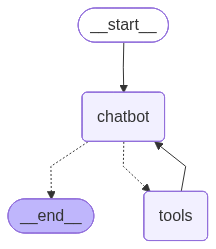

In [40]:
try : 
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [41]:
config = {'configurable': {'thread_id': '1'}}

In [43]:
user_input = 'Hi there! My name is Will.'
events = graph.stream(
    {'messages': [('user', user_input)]}, config, stream_mode='values'
)
for event in events:
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Will.
================================== Ai Message ==================================

Hello Will! How can I assist you today?


In [44]:
user_input = 'Remember my name?'
events = graph.stream(
    {'messages': [('user', user_input)]}, config, stream_mode='values'
)
for event in events:
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Remember my name?
================================== Ai Message ==================================

Yes, your name is Will! How can I help you today?


In [48]:
events = graph.stream(
    {'messages':[('user', user_input)]},
    {'configurable':{'thread_id': '1'}},
    stream_mode='values',    
)
for event in events:
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Remember my name?
================================== Ai Message ==================================

Yes, I remember! Your name is Will. What would you like to talk about?


In [46]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='Hi there! My name is Will.', additional_kwargs={}, response_metadata={}, id='e5125e3a-3b1e-4f4e-885b-aaa08f2018b1'), HumanMessage(content='Hi there! My name is Will.', additional_kwargs={}, response_metadata={}, id='250b2a56-fff9-46b1-90c7-fd0060ba8301'), AIMessage(content='Hello Will! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 93, 'total_tokens': 104, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_77c1b30b18', 'id': 'chatcmpl-DXkJVRwfGCj8RmYbuzkxC9b0FwBPj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019db997-c42b-7281-9002-cae7eb29e30a-0', to

In [47]:
snapshot.next

()